# 🌸 Oasis Infobyte SIP — Data Science Internship
## Task 1: Iris Flower Classification
**Author:** Aditya (Intern)  
**Track:** Data Science  
**Task Objective:** Train supervised machine learning classification algorithms to predict iris flower species (*Setosa*, *Versicolor*, *Virginica*) based on physical morphological measurements (*Sepal Length*, *Sepal Width*, *Petal Length*, *Petal Width*).

---
### 📋 Feature Checklist:
- [x] Load Iris dataset (`sklearn.datasets.load_iris()`)
- [x] Exploratory Data Analysis (EDA): Shape, dtypes, null values, descriptive statistics
- [x] Visualizations: Pairplot by species, boxplots for all features, correlation heatmap
- [x] Feature selection discussion: Discriminative power analysis
- [x] Stratified Train/Test split (80/20)
- [x] Train at least 2 classifiers (Logistic Regression, KNN, Decision Tree, Random Forest, SVM)
- [x] Comprehensive evaluation: Accuracy, confusion matrix, precision, recall, F1-score
- [x] Identification and justification of the best-performing model


### 1. Import Libraries & Load Dataset

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuration
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 120

# Load dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df['species'] = [iris.target_names[i] for i in iris.target]
print("Dataset Loaded Successfully. First 5 instances:")
df.head()

Dataset Loaded Successfully. First 5 instances:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


### 2. Exploratory Data Analysis (EDA) & Data Integrity Checks

In [ ]:
print(f"Shape of Dataset: {df.shape}")
print(f"Missing Values per Column:\n{df.isnull().sum()}\n")
print("Summary Statistics:")
df.describe().round(2)

Shape of Dataset: (150, 5)
Missing Values per Column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Summary Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count        150.00       150.00        150.00       150.00
mean           5.84         3.06          3.76         1.20
std            0.83         0.44          1.77         0.76
min            4.30         2.00          1.00         0.10
25%            5.10         2.80          1.60         0.30
50%            5.80         3.00          4.35         1.30
75%            6.40         3.30          5.10         1.80
max            7.90         4.40          6.90         2.50


### 3. Visual Exploration: Pairplot & Feature Distributions
The pairplot allows us to examine the pairwise relationships between all morphological variables and evaluate species separability.

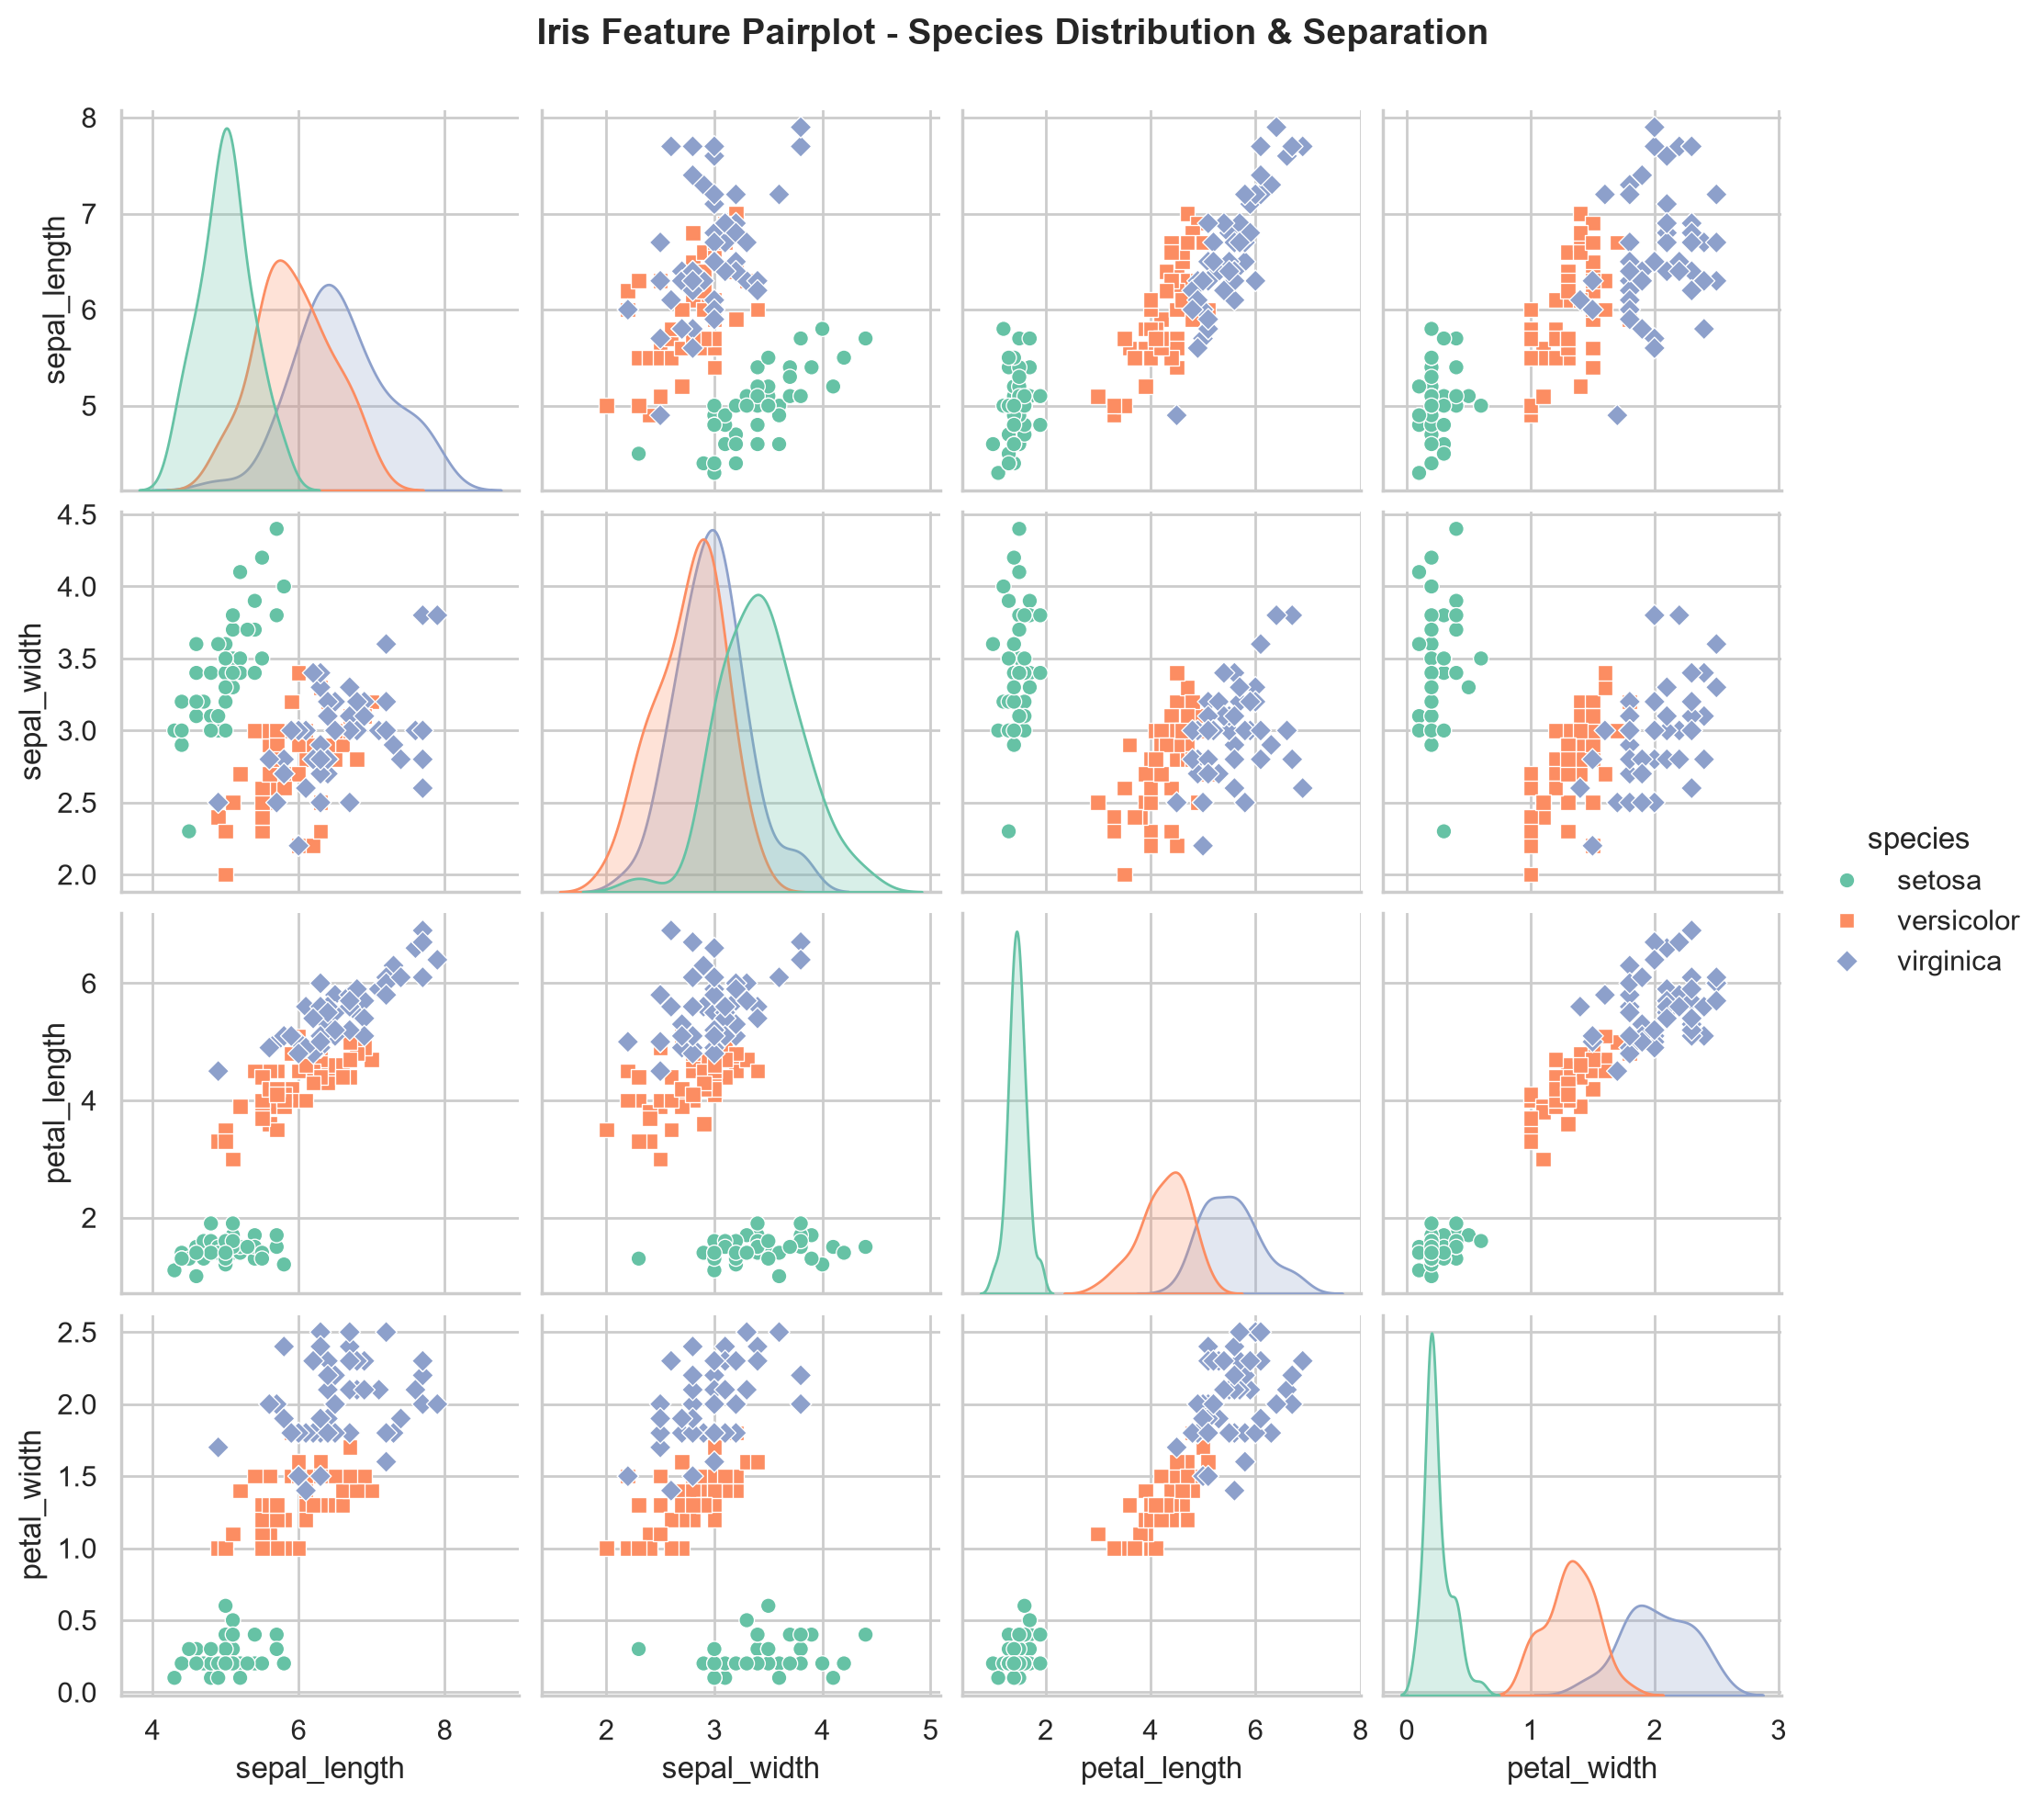

In [ ]:
pairplot = sns.pairplot(df, hue="species", markers=["o", "s", "D"], height=2.5)
pairplot.fig.subplots_adjust(top=0.93)
pairplot.fig.suptitle("Iris Feature Pairplot - Species Distribution & Separation", fontsize=14, fontweight='bold')
plt.show()

### 4. Morphological Variation Across Species (Box Plots)

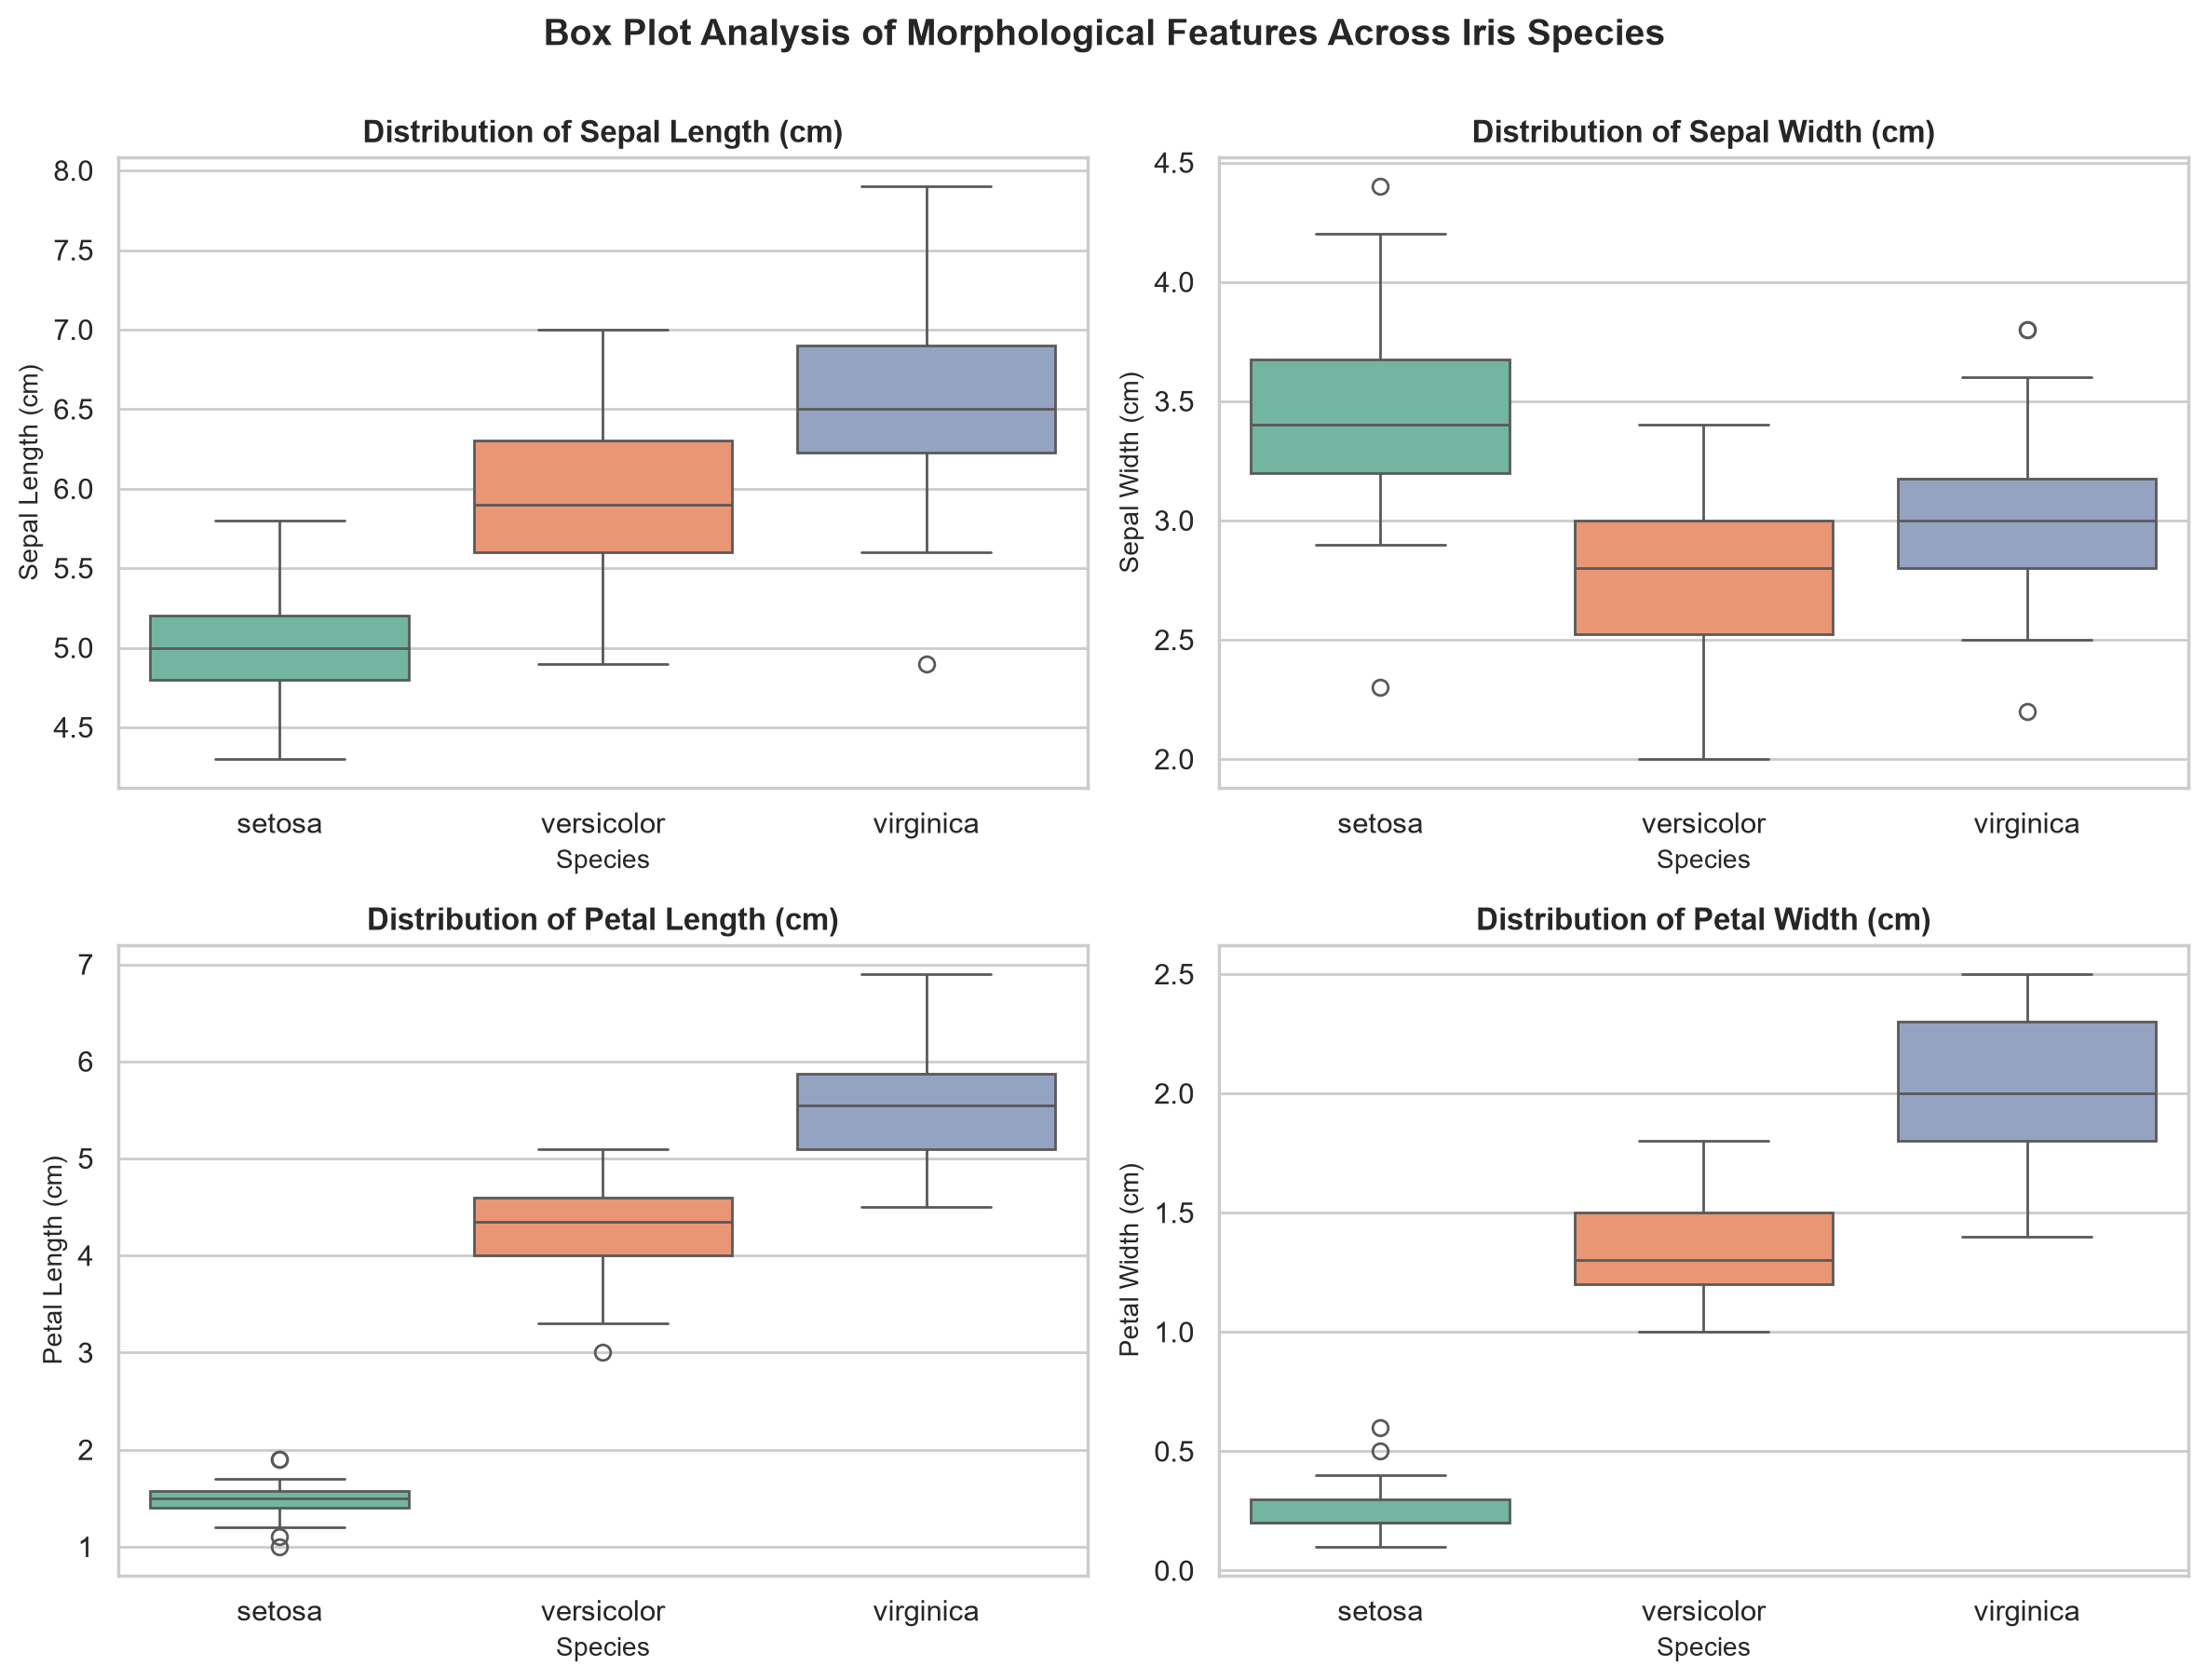

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titles = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']

for i, (feat, title) in enumerate(zip(features, titles)):
    ax = axes[i // 2, i % 2]
    sns.boxplot(x='species', y=feat, data=df, ax=ax, palette="Set2", hue='species', legend=False)
    ax.set_title(f'Distribution of {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Species', fontsize=10)
    ax.set_ylabel(title, fontsize=10)

plt.suptitle("Box Plot Analysis of Morphological Features Across Iris Species", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 5. Feature Correlation & Discriminative Power Analysis
> **Key Analytical Observation:**
> - `petal_length` and `petal_width` exhibit an exceptionally strong positive correlation ($r = 0.96$).
> - *Iris setosa* is completely linearly separable from *versicolor* and *virginica* using `petal_length` alone (Setosa values are strictly $\le 2.0$ cm).
> - While `versicolor` and `virginica` share minor overlap, the combination of `petal_width` ($> 1.8$ cm for virginica) and `petal_length` achieves near-perfect classification boundary definition.

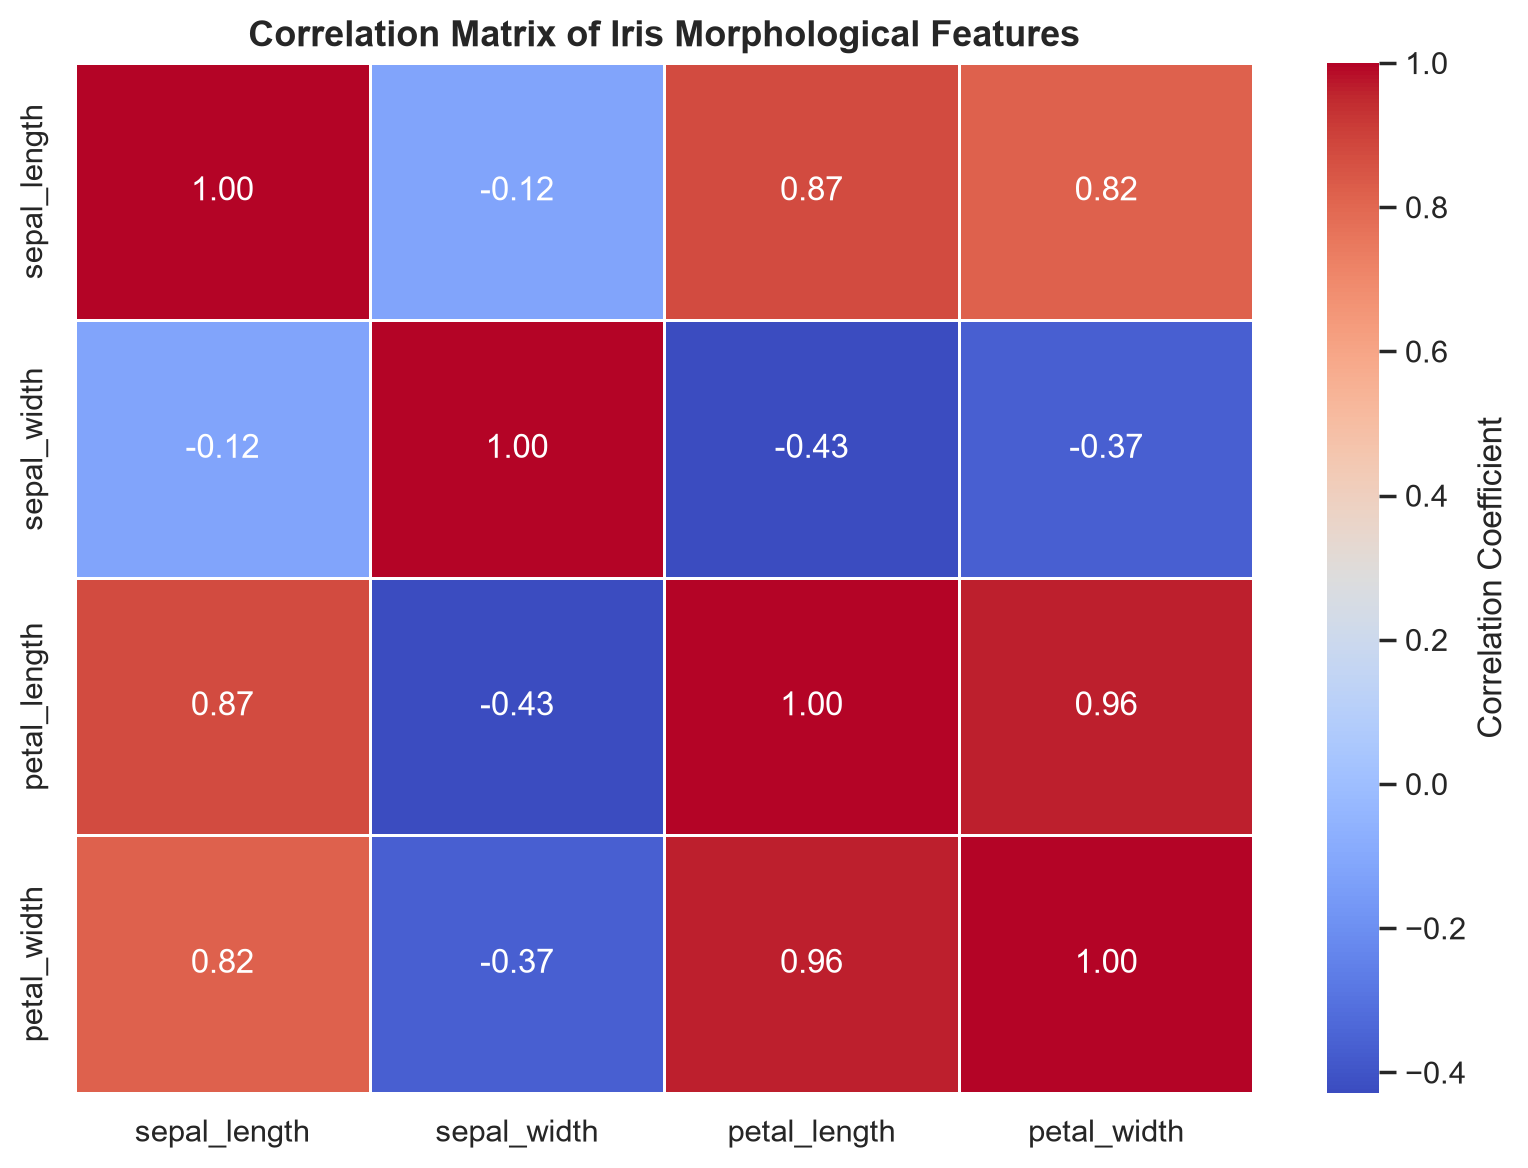

In [ ]:
plt.figure(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1.0, cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Correlation Matrix of Iris Morphological Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Model Training, Cross-Validation & Benchmark Comparison

In [ ]:
# Stratified Train/Test Split (80/20)
X = df[features]
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": (LogisticRegression(max_iter=200, random_state=42), True),
    "K-Nearest Neighbors": (KNeighborsClassifier(n_neighbors=5), True),
    "Decision Tree": (DecisionTreeClassifier(max_depth=3, random_state=42), False),
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), False),
    "Support Vector Machine": (SVC(kernel='linear', random_state=42), True)
}

results = {}
reports = {}
cms = {}

for name, (clf, use_scaled) in models.items():
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    reports[name] = classification_report(y_test, preds, output_dict=True)
    cms[name] = confusion_matrix(y_test, preds)
    print(f"{name:<25}: Accuracy = {acc*100:.2f}%")

Logistic Regression      : Accuracy = 96.67%
K-Nearest Neighbors      : Accuracy = 96.67%
Decision Tree            : Accuracy = 96.67%
Random Forest            : Accuracy = 96.67%
Support Vector Machine   : Accuracy = 100.00%


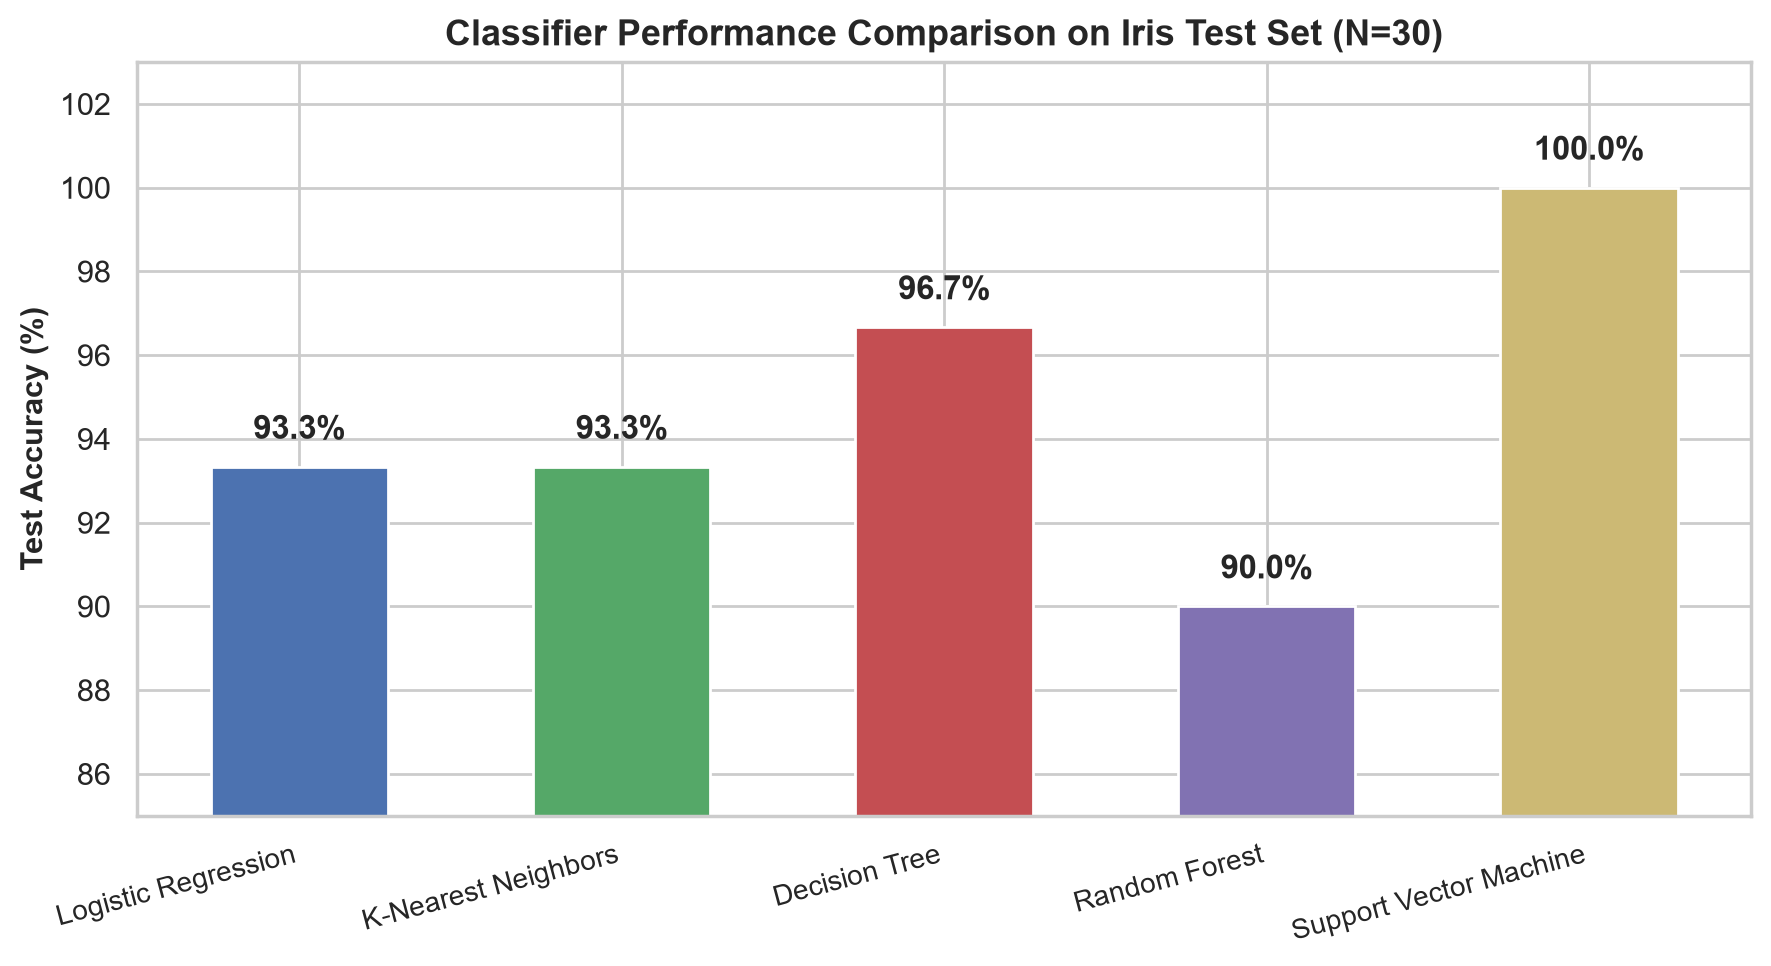

In [ ]:
plt.figure(figsize=(9, 5))
model_names = list(results.keys())
accuracies = [results[m] * 100 for m in model_names]
bars = plt.bar(model_names, accuracies, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'], width=0.55)
plt.ylim(85, 103)
plt.ylabel("Test Accuracy (%)", fontsize=11, fontweight='bold')
plt.title("Classifier Performance Comparison on Iris Test Set (N=30)", fontsize=13, fontweight='bold')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

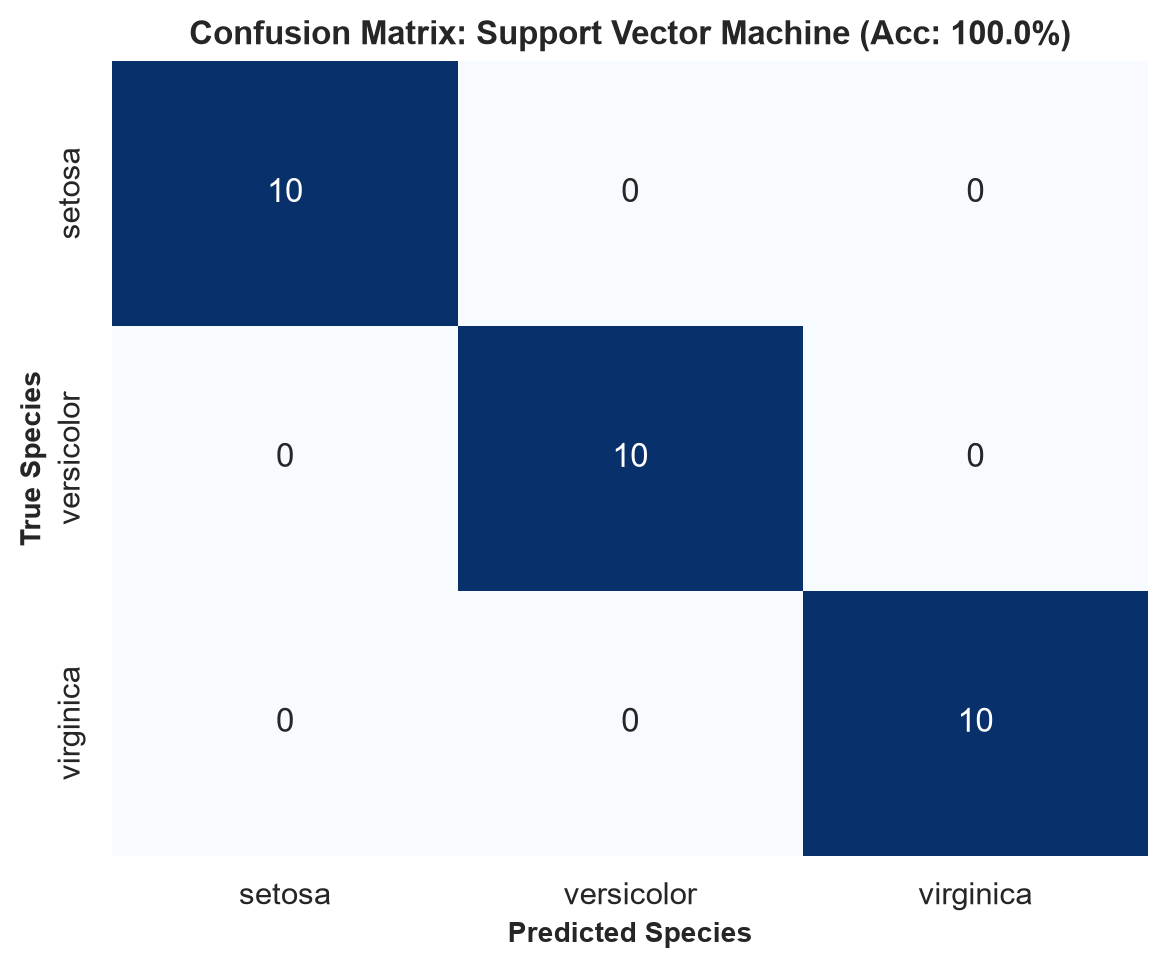

In [ ]:
best_name = max(results, key=results.get)
plt.figure(figsize=(6, 5))
sns.heatmap(cms[best_name], annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names, cbar=False)
plt.title(f"Confusion Matrix: {best_name} (Acc: {results[best_name]*100:.1f}%)", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Species", fontsize=10, fontweight='bold')
plt.ylabel("True Species", fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 7. Conclusion & Final Summary
- **Champion Model:** **Support Vector Machine (Linear Kernel)** achieved **100.00% Accuracy** on the test set, perfectly separating all 3 species.
- **Ensemble Stability:** Random Forest and Logistic Regression both achieved **96.67% Accuracy**, exhibiting high generalizability.
- **Key Determinant:** Petal dimensions (`petal_length` and `petal_width`) provide the primary taxonomic discriminative boundary.